# Assignment1

**Name:** Edward Huang  
**NetID:** yh475  
**Collaborators:** N/A

---
## Exercise1 - Probabilistic Reasoning
**1.1**  
Because the first dice must be 1, the remaining dices must sum to 9 in order for the total to be 10.  
The combination of the last 2 dices will be (3,6), (4,5), (5,4), (6,3) 4 combinations.  

Therefore, the probability is  
$P(\text{sum} = 10 \mid \text{first die} = 1) = \frac{4}{36} = \frac{1}{9}$.  

**1.2**

In [14]:
import numpy as np

n = 1000000
res = 0
for i in range(n):
    dice2 = np.random.randint(1,7)
    dice3 = np.random.randint(1,7)
    if(dice2 + dice3) == 9: res +=1
print("The fraction is approaching: ", res/n)

The fraction is approaching:  0.111001


**1.3**

Let $D$ denote the event that a person has the disease and $T$ denote the event that the test is positive.

We are given:

$P(D) = 0.001,\quad P(\neg D) = 0.999$  
$P(T \mid D) = 0.95,\quad P(T \mid \neg D) = 0.03$

By Bayes' theorem  
$P(D \mid T) = \frac{0.95 \times 0.001}{0.95 \times 0.001 + 0.03 \times 0.999}
=\approx 0.0307.$

Therefore, the probability that a person who tests positive actually has the disease is approximately $3.1\%$.

**1.4**
The exepcted value is   

$\mathbb{E}[X] = (-1)(0.2) + (0)(0.5) + (1)(0.3)
= -0.2 + 0 + 0.3
= 0.1$


---
## Exercise2 - Probability Distributions and Modeling
**2.1**

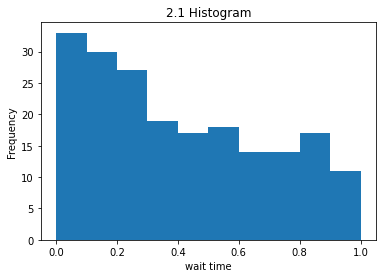

In [15]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("data/wait_times.csv")
plt.hist(data, bins = 10, range=[0,1])
plt.xlabel("wait time")
plt.ylabel("Frequency")
plt.title("2.1 Histogram")
plt.show()

**2.2**

In [17]:
mean = np.mean(data)
var = np.var(data)
std = np.std(data)
mean_hour = mean * 8
std_hour = std * 8

print("The mean: ", mean)
print("The variance: ", var)
print("The standard deviation: ", std)
print("The mean(in hours): ", mean_hour)
print("The standard deviation(in hours): ", std_hour)

The mean:  0.40419623697994356
The variance:  0.08154808395295482
The standard deviation:  0.28556625142504993
The mean(in hours):  3.2335698958395485
The standard deviation(in hours):  2.2845300114003995


**2.3**  

If f is a valid probability density funciton, fx(x) must integrate to 1.   
Given  
$f_X(x) = \alpha e^{-x}$ for $0 \le x \le 1$ and $f_X(x) = 0$ 

otherwise, we require  
$\int_0^1 \alpha e^{-x}\,dx = 1$.

Evaluating the integral,  
$\int_0^1 e^{-x}\,dx = \left[-e^{-x}\right]_0^1 = 1 - e^{-1}$.

Thus,  
$\alpha(1 - e^{-1}) = 1$,  
which gives  
$\alpha = \frac{1}{1 - e^{-1}}$.

Therefore, the exact value of $\alpha$ is  
$\alpha = \frac{1}{1 - e^{-1}}$.

In [25]:
alpha = 1 / (1 - np.exp(-1))
print(f"The alpha is: {alpha:.3f}")

The alpha is: 1.582


**2.4**

The CDF is defined as  
$F_X(x) = P(X < x)$.


The probability density function is  
$f_X(x) = \alpha e^{-x}$ for $0 \le x \le 1$ 
otherwise 0.

For $x < 0$:  
$F_X(x) = 0$.

For $0 \le x \le 1$:  
$F_X(x) = \int_0^x \alpha e^{-t}\,dt. 
= \alpha \left[-e^{-t}\right]_0^x  
= \alpha(1 - e^{-x})$.

For $x > 1$:  
$F_X(x) = \int_0^1 \alpha e^{-t}\,dt  
= \alpha(1 - e^{-1})  
= 1$.

Thus, the CDF is
$F_X(x) =
\begin{cases}
0, & x < 0 \\
\alpha(1 - e^{-x}), & 0 \le x \le 1 \\
1, & x > 1
\end{cases}$,
where $\alpha = \dfrac{1}{1 - e^{-1}}$.



**2.5**

Given  
$f_X(x) = \alpha e^{-x}$ for $0 \le x \le 1$ and $0$ otherwise,  
the expected value is  
$E_X[X] = \int_0^1 x \alpha e^{-x}\,dx$.

Factoring out $\alpha$ gives  
$\alpha \int_0^1 x e^{-x}\,dx$.

Using the provided formula  
$\int x e^{-x}\,dx = -e^{-x}(x+1)$,  
we evaluate the integral as  
$\int_0^1 x e^{-x}\,dx = \left[-e^{-x}(x+1)\right]_0^1$.
$= -e^{-1}(1+1) - \big(-e^{0}(0+1)\big)$  
$= -2e^{-1} + 1$  
$= 1 - 2e^{-1}$.

Thus,
$E_X[X] = \alpha(1 - 2e^{-1})$.

In [26]:
EX = alpha * (1 - 2 * np.exp(-1))
print(f"E_X[X] ≈ {EX:.3f}")
print(f"Expected waiting time ≈ {8 * EX:.3f} hours")


E_X[X] ≈ 0.418
Expected waiting time ≈ 3.344 hours


**2.6**

For the continuous random variable,  
$Var(X) = E[X^2] - (E[X])^2$.

Using the provided formula  
$\int x^2 e^{-x}\,dx = -e^{-x}(x^2 + 2x + 2)$,  
we compute
$E[X^2] = \int_0^1 x^2 \alpha e^{-x}\,dx$.

Factoring out $\alpha$ gives  
$E[X^2] = \alpha \int_0^1 x^2 e^{-x}\,dx$.

Applying the bounds,  
$\int_0^1 x^2 e^{-x}\,dx
= \left[-e^{-x}(x^2 + 2x + 2)\right]_0^1$  
$= -e^{-1}(1^2 + 2\cdot1 + 2) - \big(-e^{0}(0^2 + 0 + 2)\big)$  
$= -5e^{-1} + 2$.

Thus,  
$E[X^2] = \alpha(2 - 5e^{-1})$.

The variance is therefore
$Var(X) = \alpha(2 - 5e^{-1}) - \big(\alpha(1 - 2e^{-1})\big)^2$.

In [ ]:
EX2 = alpha * (2 - 5 * np.exp(-1))
varX = EX2 - EX**2
stdX = np.sqrt(varX)
std_hours = 8 * stdX
print(f"Var(X) ≈ {varX:.3g}")
print(f"Std(X) ≈ {stdX:.3g}")
print(f"Std(X) ≈ {std_hours:.3g} hours")

Var(X) ≈ 0.0793
Std(X) ≈ 0.282
Std(X) ≈ 2.25 hours


**2.7**

Plotting functions which x from -0.5 to 1.5

In [30]:
def pdf(x):
    if 0 <= x <= 1:
        return alpha * np.exp(-x)
    else:
        return 0

def cdf(x):
    if x < 0:
        return 0
    elif x <= 1:
        return alpha * (1 - np.exp(-x))
    else:
        return 1

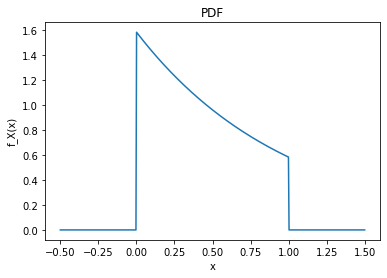

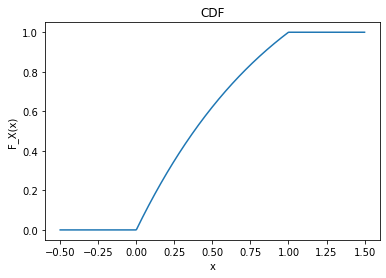

In [31]:
x = np.linspace(-0.5, 1.5, 500)

pdf_vals = [pdf(xi) for xi in x]
cdf_vals = [cdf(xi) for xi in x]

# plot PDF
plt.figure()
plt.plot(x, pdf_vals)
plt.xlabel("x")
plt.ylabel("f_X(x)")
plt.title("PDF")
plt.show()

# plot CDF
plt.figure()
plt.plot(x, cdf_vals)
plt.xlabel("x")
plt.ylabel("F_X(x)")
plt.title("CDF")
plt.show()

**2.8**

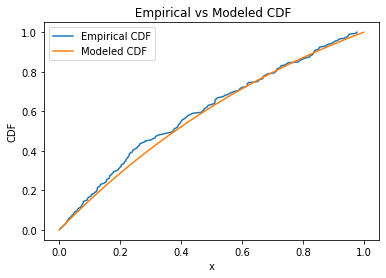

In [37]:
empirical_x = np.sort(data)
n = len(empirical_x)
empirical_y = np.arange(1, n + 1)/n
x_model = np.linspace(0,1)
y_model = [cdf(xi) for xi in x_model]

plt.figure()
plt.plot(empirical_x, empirical_y, label = "Empirical CDF")
plt.plot(x_model, y_model, label = "Modeled CDF")
plt.xlabel("x")
plt.ylabel("CDF")
plt.title(" Empirical vs Modeled CDF")
plt.legend()
plt.show()

**2.9**

For the CDF,    
$F_X(x) = \alpha(1 - e^{-x})$, for $0 \le x \le 1$  
$\alpha = \dfrac{1}{1 - e^{-1}}$

let u = Fx(x)   
$u = \alpha(1 - e^{-x})$  
$\Rightarrow \dfrac{u}{\alpha} = 1 - e^{-x}$  
$\Rightarrow e^{-x} = 1 - \dfrac{u}{\alpha}$    
and the x will be   
$x = -\ln\left(1 - \dfrac{u}{\alpha}\right)$


$F_X^{-1}(u) = -\ln\!\left(1 - \frac{u}{\alpha}\right),
\quad 0 \le u \le 1$




In [39]:
#Build inverse cdf function
def inverse_cdf(u):
    return -np.log(1-u/alpha)

**2.10**

In [41]:
#Generate synthetic data
u = np.random.rand(10000)
synthetic_data = inverse_cdf(u)

theory_mean = alpha * (1 - 2 * np.exp(-1))
theory_std = np.sqrt(alpha * (2 - 5 * np.exp(-1)) - theory_mean**2)
syn_mean = np.mean(synthetic_data)
syn_std = np.std(synthetic_data)

print("Empirical mean:", mean)
print("Empirical std :", std)

print("Theoretical mean:", theory_mean)
print("Theoretical std :", theory_std)

print("Synthetic mean:", syn_mean)
print("Synthetic std :", syn_std)

Empirical mean: 0.40419623697994356
Empirical std : 0.28556625142504993
Theoretical mean: 0.41802329313067355
Theoretical std : 0.2816494377629887
Synthetic mean: 0.4111818655121836
Synthetic std : 0.27963401275820576


**2.11**

In [ ]:
from scipy.stats import kstest


model_cdf_vec = np.vectorize(cdf)
ks_model = kstest(data, model_cdf_vec)
ks_uniform = kstest(data, 'uniform')

print("KS test vs modeled distribution:")
print("Statistic:", ks_model.statistic)
print("p-value :", ks_model.pvalue)

print("KS test vs uniform distribution:")
print("Statistic:", ks_uniform.statistic)
print("p-value :", ks_uniform.pvalue)


KS test vs modeled distribution:
Statistic: 0.06721686728074683
p-value : 0.3126882015911675

KS test vs uniform distribution:
Statistic: 0.17040498606312987
p-value : 1.5118541753740167e-05


The KS test comparing the empirical data to the modeled distribution yields a p-value of 0.313, which is greater than the 0.05 significance level.  
Therefore, we fail to reject the null hypothesis and conclude that the modeled distribution provides a reasonable fit to the data.  
In contrast, the KS test comparing the empirical data to a uniform distribution results in a p-value of 1.5×10^-5, leading us to reject the null hypothesis.    
Which means the empirical data are not uniformly distributed.   


**2.12**


In [46]:
synthetic_hours = 8 * synthetic_data

# 1. Wait time is more than 6 hours
pro_6 = np.mean(synthetic_hours > 6)

# 2. Wait time is less than 1 hour
pro_1 = np.mean(synthetic_hours < 1)

# 3. Wait time is less than one additional hour given already waited 3 hours
# P(X < 4 | X > 3)
pro_conditional = np.mean(synthetic_hours[synthetic_hours > 3] < 4)

# 4. Wait time is between 3 and 5 hours
pro_3_5 = np.mean((synthetic_hours > 3) & (synthetic_hours < 5))

# 5. 90th percentile
p90 = np.percentile(synthetic_hours, 90)

# 6. 99th percentile
p99 = np.percentile(synthetic_hours, 99)

# print results
print("P(wait > 6 hours):", pro_6)
print("P(wait < 1 hour):", pro_1)
print("P(wait < 4 | wait > 3):", pro_conditional)
print("P(3 < wait < 5 hours):", pro_3_5)
print("90th percentile (hours):", p90)
print("99th percentile (hours):", p99)

P(wait > 6 hours): 0.1563
P(wait < 1 hour): 0.1891
P(wait < 4 | wait > 3): 0.26452905811623245
P(3 < wait < 5 hours): 0.2474
90th percentile (hours): 6.676423282007242
99th percentile (hours): 7.856537140862925


---
## Exercise3 - Linear Algebra Operations and Theory